In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import numpy as np
import pandas as pd
from scipy.signal import detrend
from scipy.stats import gmean

# plotting
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import seaborn as sns

sns.set_theme('notebook', style='ticks')
plt.style.use("dark_background")
plt.rcParams.update({
    "figure.facecolor":  (0, 0, 0, 0),
    "axes.facecolor":    (0, 0, 0, 0),
    "savefig.facecolor": (0, 0, 0, 0),
})


# multitaper
import multitaper
import libtfr

import sys
sys.path.append('../../../PycharmProjects/orca5/')
# from src.model.hallmoench import (
#     get_impulse_response, get_impulse_response2
# )
import src.wangwoerman.wangwoerman as ww

In [8]:
def power_bit_length(x):
    return int(2**(x-1).bit_length())


def load_signal(h5, from_date=None, until_date=None, sampling_period='H'):
    s = pd.HDFStore(h5).raw_data.value
    s = s.astype('float')
    s.index = pd.to_datetime(s.index)
    s.index.name = 'datetime'
    s = s.tz_localize(None)
    return s[from_date:until_date].asfreq('H')


def resample_signal(sig, sampling_period='H'):
    s = sig.dropna().resample('H').mean().resample('H').interpolate()
    s = pd.Series(index=s.index, data=detrend(s.values))
    return s


def get_spectrogram(sig, nfft, nw, k, window, shift):
    nframes = (sig.size - window) // shift + 1
    slices = [(x, x + window) for x in np.arange(nframes) * shift]
    frames_ok = np.array(
        [np.isnan(sig.values[slice(*s)]).sum() < 0.05 * np.diff(s)[0] for s in slices]
    )
    indices = np.arange(nframes) * shift + window // 2
    # create a transform object
    D = libtfr.mfft_dpss(nfft, nw, k, window)
    sig = resample_signal(sig, sampling_period=f'{pd.infer_freq(sig.index)}')
    Fs = 1 / pd.to_timedelta(f'1{pd.infer_freq(sig.index)}').total_seconds()
    f, _ = libtfr.fgrid(Fs, D.nfft)
    Z = D.mtspec(sig, shift)
    return sig.index[indices], f, np.where(frames_ok, Z, np.nan)


def cut_spectrogram(x, y, Z, xmin=None, xmax=None, ymin=None, ymax=None):
    if xmin is None:
        xmin = x.min()
    if xmax is None:
        xmax = x.max()
    if ymin is None:
        ymin = y.min()
    if ymax is None:
        ymax = y.max()
    xmask = (x>=xmin) & (x<=xmax)
    ymask = (y>=ymin) & (y<=ymax)
    return x[xmask], y[ymask], Z[ymask,:][:,xmask]


def plot_spectrogram(x, y, Z,
                     ylabel=None, cblabel=None,
                     cmap='gnuplot2', norm=mcolors.LogNorm(),
                     cbar=False,
                     figsize=None,
                     ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    pcm = ax.pcolormesh(x, y, Z, cmap=cmap, norm=norm)
    ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
    ax.set_ylabel(ylabel)
    if cbar:
        cax = plt.colorbar(pcm, ax=ax)
        cax.set_label(cblabel)
    return ax, pcm


def load_rl_and_gh_data(rl_h5, gh_h5, from_date=None, until_date=None, sampling_period='H'):
    sig_with_nan = {}
    Zdict = {}
    for l,v in zip(['gh', 'rl'], [gh_h5, rl_h5]):
        sig_with_nan[l] = load_signal(v, from_date, until_date, sampling_period)
        if from_date is None and l == 'gh':
            from_date = sig_with_nan[l].index[0]
        if until_date is None and l == 'gh':
            until_date = sig_with_nan[l].index[-1]
        
    index_min = max(sig_with_nan['rl'].index[0],
                          sig_with_nan['gh'].index[0])
    index_max = min(sig_with_nan['rl'].index[-1],
                          sig_with_nan['gh'].index[-1])
    
    for l in ['gh', 'rl']:
        sig_with_nan[l] = sig_with_nan[l][index_min: index_max]
    
    return sig_with_nan
    
    
def get_rl_and_gh_spectograms(sig_with_nan, nfft, nw, k, window, shift):
    Zdict = {}
    
    for l in ['gh', 'rl']:
        dates, freqs, Zdict[l] = get_spectrogram(sig_with_nan[l], nfft, nw, k, window, shift)
        
    return dates, freqs, Zdict
    

def plot_rl_and_gh_spectrograms(dates, freqs, Zdict,
                                ylabel=None, cblabel=None, cbar=False,
                                cmap='gnuplot2',
                                figsize=(12,4)):
    fig, ax = plt.subplots(2, 1, sharex=True, figsize=figsize)
    Z_val = np.array([Zdict[k] for k in ['rl', 'gh']]).flatten().flatten()
    
    vmin, vmax = np.nanmin(Z_val), np.nanmax(Z_val)
    cbar=True
    norm=mcolors.LogNorm(vmin, vmax)
    for i, k in enumerate(['rl', 'gh']):
        plot_spectrogram(
            dates, freqs, Zdict[k], ylabel, cblabel, cmap, norm, cbar, figsize, ax=ax[i]
        )
    return fig, ax


def g_mean(x):
    a = np.log10(x)
    return 10**(np.nanmean(a, axis=0))


def plot_series_spetra_a(ser_dict, spec_dict, R_dict, figsize=(11,6), cmap='viridis'):
    # global
    fig, axd = plt.subplot_mosaic(
        [['sp0', 'none0'], ['sp1', 'cax12'], ['sp2', 'cax12'], ['sp3', 'cax3'], ['sp4', 'none4']],
        gridspec_kw={'width_ratios': [30,1], 'height_ratios': [2,1,1,1,4]},
        figsize=figsize)  #, layout="constrained")
    plt.subplots_adjust(hspace=0.2, wspace=0.05)
    [v.remove() for k,v in axd.items() if 'none' in k]
    
    # sp0
    for k in ['rl', 'gh']:
        sig_minus_mean = sig_with_nan[k]-sig_with_nan[k].mean()
        axd['sp0'].plot(sig_minus_mean.index, sig_minus_mean, label='k')
        axd['sp0'].set_ylabel('level-mean [m]')
        
    # sp1, sp2
    Z_val = np.array([spec_dict[k]['Z'] for k in ['rl', 'gh']]).flatten().flatten()
    vmin, vmax = np.nanmin(Z_val), np.nanmax(Z_val)
    for i, k in enumerate(['rl', 'gh']):
        pcm = plot_spectrogram(
            spec_dict[k]['dates'], spec_dict[k]['freqs'], spec_dict[k]['Z'],
            cmap=cmap, norm=mcolors.LogNorm(vmin, vmax), ax=axd[f'sp{i+1}']
        )
    fig.colorbar(mappable=pcm[1], cax=axd['cax12'], label=f'PSD [m$^2$ day]')
    axd['sp2'].set_ylabel('f [cycle/day]')
    
    # sp3
    pcm = plot_spectrogram(
        R_dict['dates'], R_dict['freqs'], R_dict['R'],
        cmap=f'{cmap}_r', norm=mcolors.LogNorm(), ax=axd['sp3']
    )
    fig.colorbar(mappable=pcm[1], cax=axd['cax3'], label='R [m]')
    
    # sp4
    axd['sp4'].semilogy(dates, g_mean(R_dict['R']))  # np.mean(R_dict['R'], axis=0))
    axd['sp4'].set_ylabel('R [m]')
    axd['sp4'].set_xlim(dates[0], dates[-1])
    axd['sp4'].xaxis.set_major_locator(mdates.YearLocator(base=1))

    # global
    for k,v in axd.items():
        if k not in ['sp4', 'cax12', 'cax3', 'none0', 'none4']:
            plt.setp(v.get_xticklabels(), visible=False)
            v.sharex(axd['sp4'])
        v.set_axisbelow(True)
        if k not in ['sp4']:
            v.grid(False)
        else:
            v.grid(True)
        
    return fig, ax

In [9]:
# load river and groundwater signals
sig_with_nan = load_rl_and_gh_data(
    '../../../PycharmProjects/orca5/data/raw_data/hydro/2346_518_2002_1859.h5',
    '../../../PycharmProjects/orca5/data/raw_data/piezo/150_head_bsl.h5',
    from_date='2011-04-04', until_date=None, sampling_period='H'
)

In [14]:
def get_slices(twin, dt, olap, ser):
    nwin = int(np.round(twin / dt))
    if olap <= 0.0:
        njump = nwin
    else:
        njump = int(np.round(twin * (1.0 - olap) / dt))
    nmax = len(data) - nwin
    nvec = np.arange(0, nmax, njump)
    nspec = len(nvec)
    slices = []
    for i in range(nspec):
        slices.append(slice(i*njump, i*njump+nwin))
    slices_ok = [ser.iloc[sl].isna().sum() < 0.1*njump for sl in slices]
    middle_indices = np.array([(sl.start + sl.stop) // 2 for sl in slices])
    return np.array(slices), np.array(slices_ok), middle_indices

def set_to_nan(mat, slices_ok):
    mat1 = mat
    mat1[:, ~slices_ok] = np.nan
    return mat1

def hs_estimator(s, Pxx, Pyy, Pyx, Pxy):

    Hsa = s**2 * Pxx - Pyy + np.sqrt(
        (s**2 * Pxx - Pyy)
        + 4 * s**2 * np.abs(Pyx)**2
        ) / (2 * s**2 * Pyx)

    Hsb = 2 * Pxy / (
        Pyy
        - s**2 * Pxx
        + np.sqrt(
            (s**2 * Pxx - Pyy)
            + 4 * s**2 * np.abs(Pyx)**2
            )
    )
    return Hsa, Hsb

In [16]:
df = pd.concat(sig_with_nan, axis=1)
print(df.head())
data = df.dropna().resample('H').mean().resample('H').interpolate().to_numpy()
npts = data.shape[0]
nw = 12
k = 2*nw-1
twin = 1*28*24*60**2
olap = 1/4
dt = 60**2
slices, slices_ok, indices = get_slices(twin, dt, olap, ser=df.gh)
# print(f'{slices.size=}')
# print(f'{slices_ok=}')

                         gh       rl
datetime                            
2011-04-04 00:00:00  643.84  665.672
2011-04-04 01:00:00  643.84  665.671
2011-04-04 02:00:00  643.84  665.669
2011-04-04 03:00:00  643.84  665.665
2011-04-04 04:00:00  643.84  665.661


In [17]:
res = multitaper.mtcross.spectrogram(data, dt=dt, twin=twin, olap=olap, nw=nw, kspec=k)
r = dict(zip(['t', 'f', 'Sxx', 'Syy', 'Sxy', 'Syx', 'Cohe', 'TrF', 'Hhat1', 'Hhat2', 'Hhatv', 'Tyx'], res))

Number of variables 2
Number of variable pairs 1
Window length 2419200.0s and overlap 25%
Total number of cross-spectral estimates 201
Frequency band of interest ( 0.00- 0.00)Hz
Loop over pair  1  of  1
Loop  10  of  201
Loop  20  of  201
Loop  30  of  201
Loop  40  of  201
Loop  50  of  201
Loop  60  of  201
Loop  70  of  201
Loop  80  of  201
Loop  90  of  201
Loop  100  of  201
Loop  110  of  201
Loop  120  of  201
Loop  130  of  201
Loop  140  of  201
Loop  150  of  201
Loop  160  of  201
Loop  170  of  201
Loop  180  of  201
Loop  190  of  201
Loop  200  of  201


(<AxesSubplot: >, <matplotlib.collections.QuadMesh at 0x7fc3e0ed60d0>)

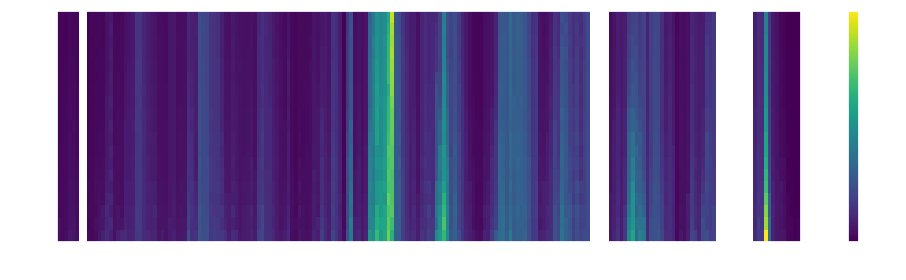

In [18]:
fig, ax = plt.subplots(figsize=(12,3))
mask = (r['f']*24*60**2 >= 2/3) & (r['f']*24*60**2 <= 1)
freqs = r['f'][mask]*24*60**2
z = set_to_nan(r['Tyx'].squeeze().real, slices_ok)[mask.flat]
plot_spectrogram(df.index[indices], freqs, z, ax=ax, cbar=True, cmap='viridis', norm=mcolors.Normalize())

(<AxesSubplot: >, <matplotlib.collections.QuadMesh at 0x7fc3e13c4a00>)

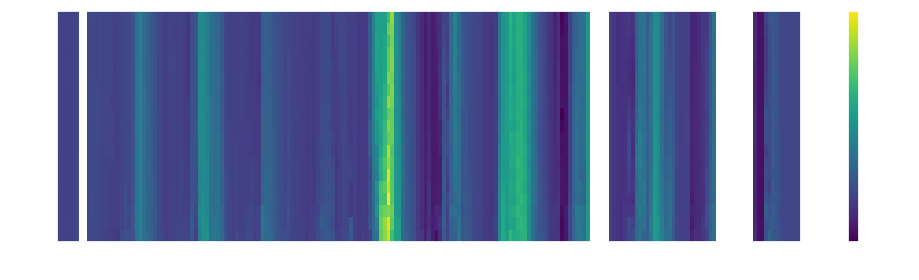

In [19]:
fig, ax = plt.subplots(figsize=(12,3))
mask = (r['f']*24*60**2 >= 2/3) & (r['f']*24*60**2 <= 1)
freqs = r['f'][mask]*24*60**2
z = set_to_nan(r['TrF'].squeeze().real, slices_ok)[mask.flat]
plot_spectrogram(df.index[indices], freqs, z, ax=ax, cbar=True, cmap='viridis', norm=mcolors.Normalize())

(<AxesSubplot: >, <matplotlib.collections.QuadMesh at 0x7fc3b3dc4820>)

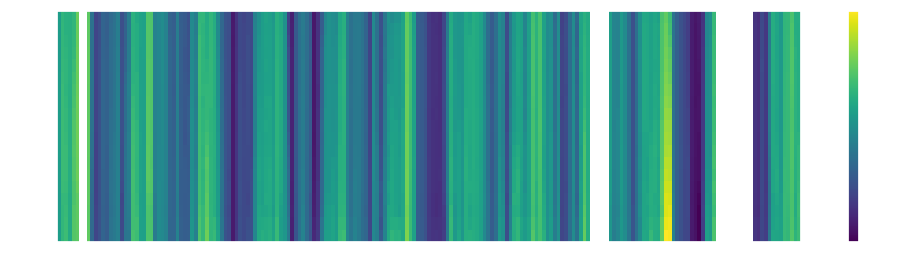

In [20]:
fig, ax = plt.subplots(figsize=(12,3))
mask = (r['f']*24*60**2 >= 2/3) & (r['f']*24*60**2 <= 1)
freqs = r['f'][mask]*24*60**2
z = set_to_nan(r['Syy'].squeeze().real, slices_ok)[mask.flat]
plot_spectrogram(df.index[indices], freqs, z, ax=ax, cbar=True, cmap='viridis')

(<AxesSubplot: >, <matplotlib.collections.QuadMesh at 0x7fc3e0fb1ca0>)

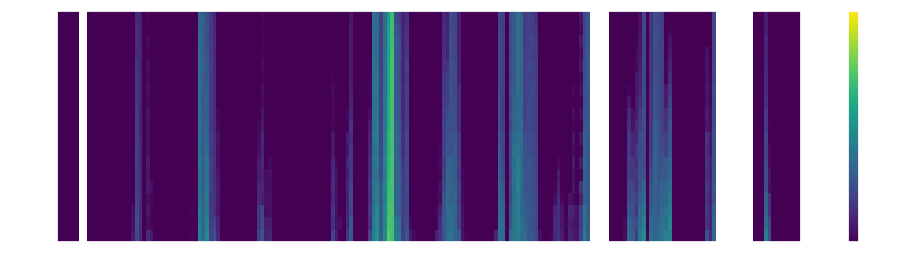

In [21]:
fig, ax = plt.subplots(figsize=(12,3))
mask = (r['f']*24*60**2 >= 2/3) & (r['f']*24*60**2 <= 1)
freqs = r['f'][mask]*24*60**2
z = set_to_nan(r['Sxx'].squeeze().real, slices_ok)[mask.flat]


In [ ]:
plot_spectrogram(df.index[indices], freqs, z, ax=ax, cbar=True, cmap='viridis')

(<AxesSubplot: >, <matplotlib.collections.QuadMesh at 0x7fbccc8704c0>)

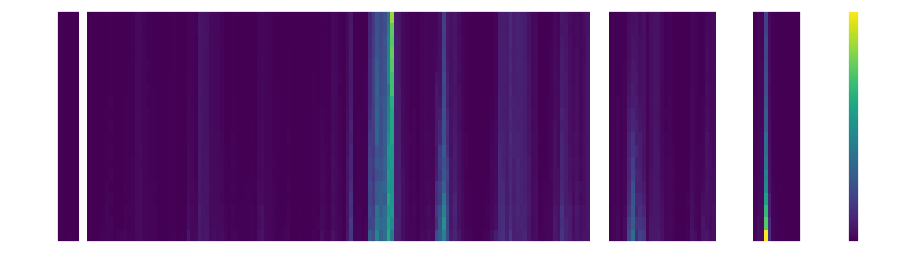

In [ ]:
fig, ax = plt.subplots(figsize=(12,3))
mask = (r['f']*24*60**2 >= 2/3) & (r['f']*24*60**2 <= 1)
freqs = r['f'][mask]*24*60**2
Pr = set_to_nan(r['Syy'].squeeze().real, slices_ok)[mask.flat]
P = set_to_nan(r['Sxx'].squeeze().real, slices_ok)[mask.flat]
plot_spectrogram(df.index[indices], freqs, P/Pr, ax=ax, cbar=True, cmap='viridis', norm=mcolors.Normalize())

(<AxesSubplot: >, <matplotlib.collections.QuadMesh at 0x7fc3e07b9e50>)

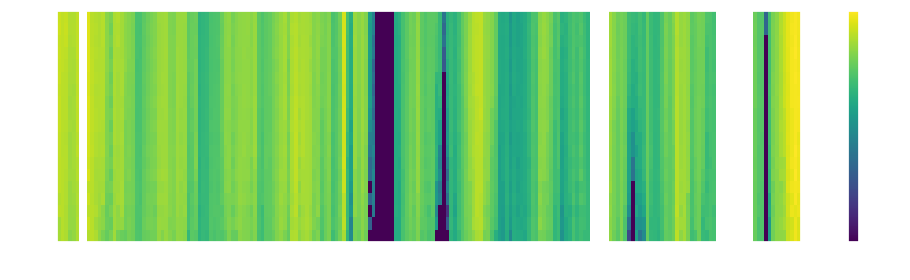

In [32]:
fig, ax = plt.subplots(figsize=(12,3))
mask = (r['f']*24*60**2 >= 2/3) & (r['f']*24*60**2 <= 1)
Pr = set_to_nan(r['Syy'].squeeze().real, slices_ok)[mask.flat]
P = set_to_nan(r['Sxx'].squeeze().real, slices_ok)[mask.flat]
freqs = r['f'][mask]
R_Tyx = ww.resistance_spectrum(np.sqrt(Pr), np.sqrt(P), 2*np.pi*np.tile(freqs,(Pr.shape[1],1)).T, 45, 10, min_r=1)
plot_spectrogram(df.index[indices], freqs*24*60**2, R_Tyx, ax=ax, cbar=True, cmap='viridis', norm=mcolors.LogNorm())

(<AxesSubplot: >, <matplotlib.collections.QuadMesh at 0x7fc3e0891ac0>)

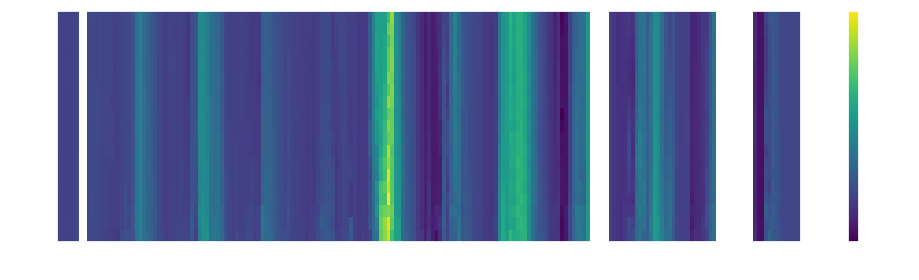

In [23]:
fig, ax = plt.subplots(figsize=(12,3))
mask = (r['f']*24*60**2 >= 2/3) & (r['f']*24*60**2 <= 1)
freqs = r['f'][mask]*24*60**2
Pr = set_to_nan(r['Syy'].squeeze().real, slices_ok)[mask.flat]
P = set_to_nan(r['Sxy'].squeeze().real, slices_ok)[mask.flat]
plot_spectrogram(df.index[indices], freqs, P/Pr, ax=ax, cbar=True, cmap='viridis', norm=mcolors.Normalize())

/home/olivier/devel/multitaper/multitaper/examples/../../../PycharmProjects/orca5/src/wangwoerman/wangwoerman.py:107: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(sqrt_term) - 1


(<AxesSubplot: >, <matplotlib.collections.QuadMesh at 0x7fc3dc2be160>)

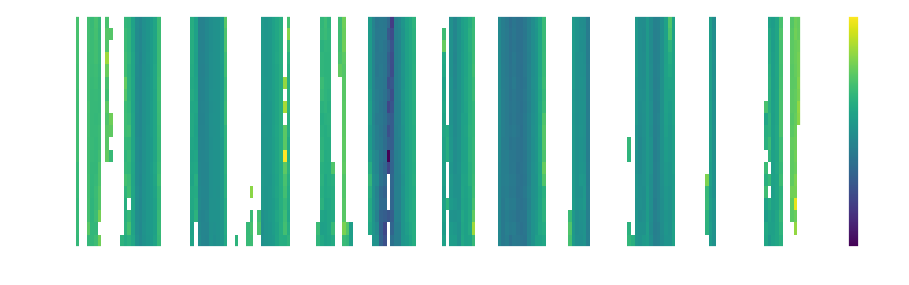

In [29]:
fig, ax = plt.subplots(figsize=(12,3))
mask = (r['f']*24*60**2 >= 2/3) & (r['f']*24*60**2 <= 1)
Pr = set_to_nan(r['Syy'].squeeze().real, slices_ok)[mask.flat]
P = set_to_nan(r['Sxy'].squeeze().real, slices_ok)[mask.flat]
freqs = r['f'][mask]
R_H1 = ww.resistance_spectrum(Pr, P, 2*np.pi*np.tile(freqs,(Pr.shape[1],1)).T, 45, 10, min_r=None)
plot_spectrogram(df.index[indices], freqs*24*60**2, R_H1, ax=ax, cbar=True, cmap='viridis', norm=mcolors.LogNorm())

/tmp/ipykernel_12183/1768578348.py:5: RuntimeWarning: Mean of empty slice
  ax.semilogy(df.index[indices], np.nanmean(R_H1, axis=0), lw=5)


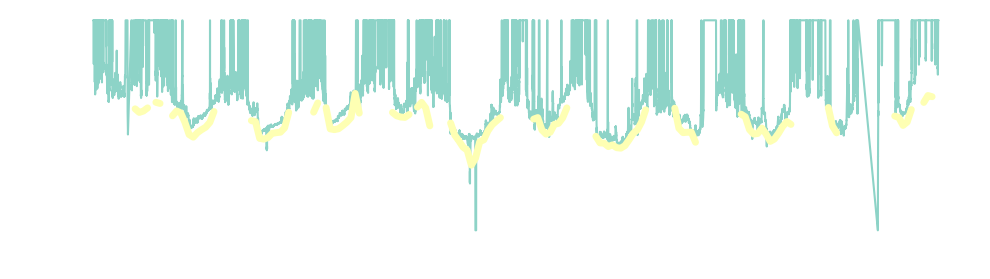

In [30]:
fig, ax = plt.subplots(figsize=(12,3))
with pd.HDFStore('../../../PycharmProjects/orca5/data/output/2346__150__.h5') as store:
    a = 10**store.piezo.popt.tz_convert(None)['2011':]
ax.semilogy(a.index, a)
ax.semilogy(df.index[indices], np.nanmean(R_H1, axis=0), lw=5)
ax.xaxis.set_major_locator(mdates.YearLocator(base=1))

In [ ]:
nw = 12
window = sig_with_nan['gh'].size
k = 2*nw-1
tapers, lambdas = libtfr.dpss(window, nw, k)

In [ ]:
lambdas

array([1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       0.99999995, 0.99999946, 0.99999431, 0.99994647, 0.99955324,
       0.99673423, 0.97972382, 0.90099705])

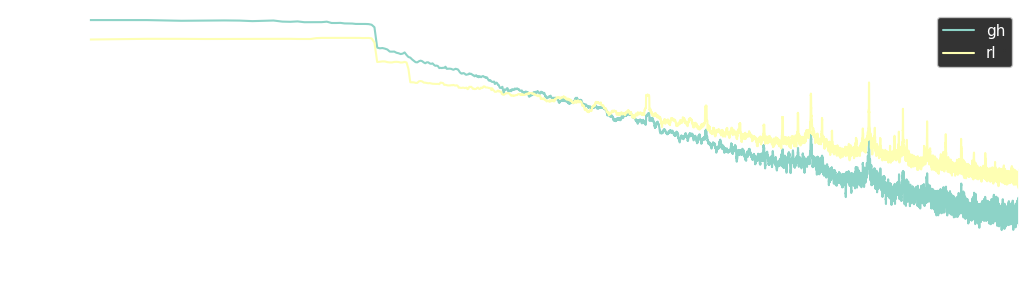

In [ ]:
# specta estimation and plot
nw = 12
window = sig_with_nan['gh'].size
k = 2*nw-1
transform = libtfr.mfft_dpss(
    nfft=power_bit_length(window),  # number of points in the transform
    nw=nw,  # time-frequency parameter
    ntapers=k,  # number of tapers to generate (kspec = 2*nw-1)
    npoints=window,  # number of points in the taper (window)
)
sec_per_day = 24*60**2
Z = {}
fig, ax = plt.subplots(figsize=(12,3))
for l,v in sig_with_nan.items():
    # transform a time series
    sig = resample_signal(sig_with_nan[l], sampling_period='H')
    Z[k] = transform.mtpsd(sig) / 24
    Fs = 1 / pd.to_timedelta(f'1{pd.infer_freq(sig.index)}').total_seconds()
    f, idx = libtfr.fgrid(Fs, transform.nfft)  # frequencies in Hz
    f1 = f * sec_per_day
    ax.loglog(f1, Z[k][idx], label=l)
    ax.set_xlim(f1[1], f1[-1])
ax.set_ylabel(r'PSD [m$^2$ day]')
ax.set_xlabel('Frequency [cycle/day]')
ax.legend()
ax.grid();
# sig2 = resample_signal(sig_with_nan['gh'], sampling_period='H')
# freqs2 = np.fft.rfftfreq(sig2.size, d=60**2) * sec_per_day
# print(freqs2)
# fft2 = np.fft.rfft(sig2)
# psd2 = np.abs(fft2)**2 / sec_per_day
# ax.plot(freqs2, np.abs(psd2), zorder=-1)
# ax.set_ylim(1e-8, 1e3)

J'obtiens des résultats identiques à ceux obtenus avec la toolbox de Prieto.
Le PSD obtenu avec la fonction "mtpsd" est en unité du signal au carré multiplié par le pas de temps d'échantillonage. Dans mon cas, comme le pas de temps de mesure est d'une heure, le PSD est retourné en [m$^2$ hour]. Je le divise par 24 pour avoir des [m$^2$ day].

In [ ]:
window = 1*28*24
nfft = power_bit_length(window)
shift = window//4
nw = 12
k = int(2*nw-1)
dates, freqs, Zdict = get_rl_and_gh_spectograms(sig_with_nan, nfft, nw, k, window, shift)

Pour le graphique il faut changer l'uninté des spectrograms ([m$^2$ hour] -> [m$^2$ day]) et celle des fréquences ([Hz] -> [cycle/day]).

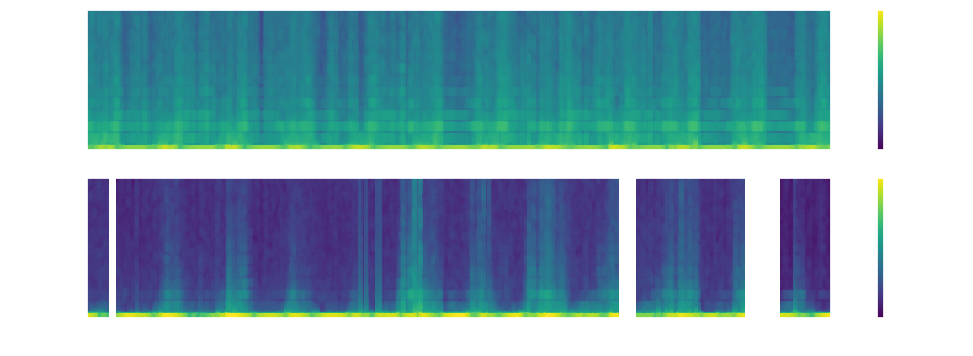

In [ ]:
plot_rl_and_gh_spectrograms(dates, freqs*sec_per_day, {k:v/24 for k,v in Zdict.items()},
                            ylabel='Frequency\n[cycle/day]',
                            cbar=True,
                            cblabel=r'PSD [m$^2$ day]',
                            cmap='viridis',
                            figsize=(12,4));

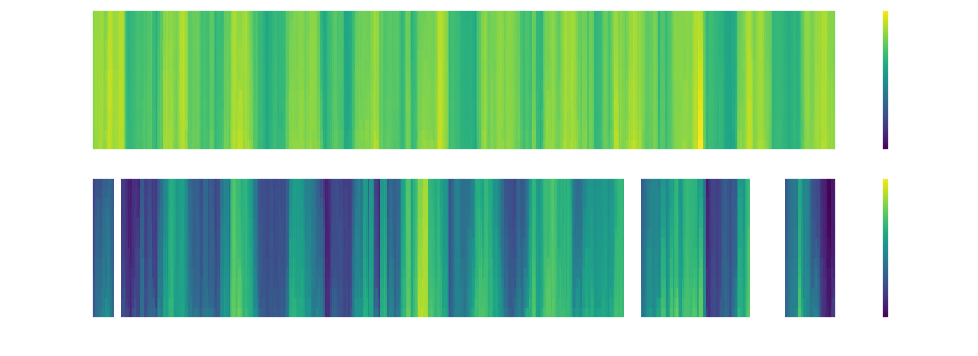

In [ ]:
Zdict1 = {}
for k in ['rl', 'gh']:
    dates1,  freqs1, Zdict1[k] = cut_spectrogram(
        dates, freqs*sec_per_day, Zdict[k]/24, ymin=2/3, ymax=1
    )

plot_rl_and_gh_spectrograms(dates1, freqs1, Zdict1,
                            ylabel='Frequency\n[cycle/day]',
                            cblabel=r'PSD [m$^2$ day]',
                            cmap='viridis',
                            figsize=(12,4));

In [ ]:
alpha = 10  # diffusivity
omega = 2*np.pi*freqs[1:]
omega = np.tile(omega, (Zdict['rl'][1:,:].shape[1], 1)).T
print(Zdict['rl'][1:,:]/Zdict['gh'][1:,:])
R = ww.resistance_spectrum(
    Zdict['rl'][1:,:], Zdict['gh'][1:,:], omega, x=45, a=alpha, min_r=None
)

[[2.18903881e-02 2.67366389e-02 2.80015499e-02 ... 2.16983968e-02
  2.92742276e-02 3.97187022e-02]
 [2.18671694e-02 2.66246038e-02 2.80456713e-02 ... 2.14492778e-02
  2.88354915e-02 3.95750387e-02]
 [2.20316412e-02 2.64930801e-02 2.77521618e-02 ... 2.12476002e-02
  2.90448760e-02 3.91128640e-02]
 ...
 [1.55164101e+02 9.74519776e+01 1.64095765e+02 ... 2.97986865e+03
  1.50557185e+03 1.19828128e+03]
 [1.56996366e+02 1.02280293e+02 1.56930101e+02 ... 2.63354252e+03
  1.45313006e+03 1.23290937e+03]
 [1.66570281e+02 1.06165447e+02 1.58081548e+02 ... 2.49037340e+03
  1.44011427e+03 1.20081786e+03]]


/home/olivier/devel/multitaper/multitaper/examples/../../../PycharmProjects/orca5/src/wangwoerman/wangwoerman.py:107: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt(sqrt_term) - 1


$\alpha$ [m$^2$/s]; $\omega=2\pi f$ [rad/s]; R [m]

/tmp/ipykernel_133069/2731900590.py:115: RuntimeWarning: invalid value encountered in log
  a = np.log(x)
/tmp/ipykernel_133069/2731900590.py:116: RuntimeWarning: Mean of empty slice
  return np.exp(np.nanmean(a, axis=0))


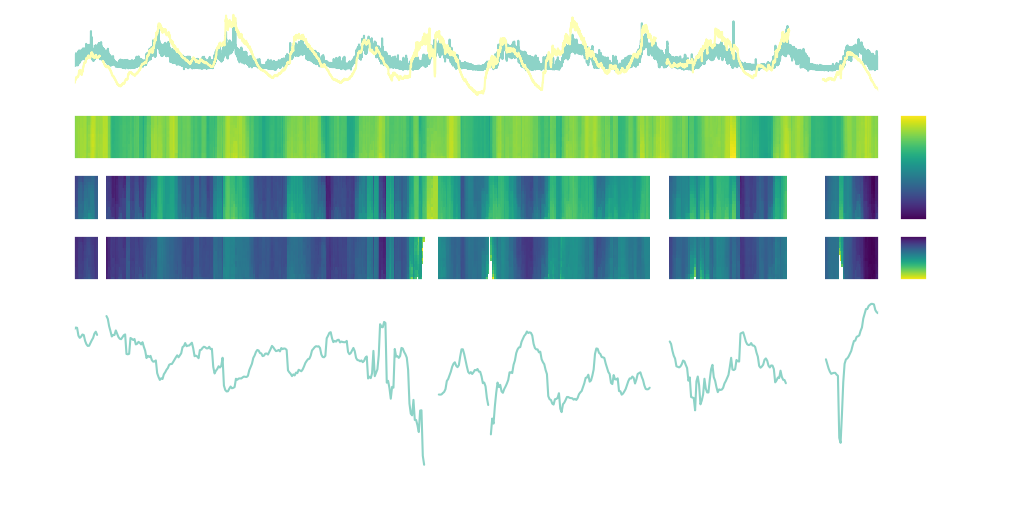

In [ ]:
spec_dict = {'rl': {'dates': None, 'freqs': None, 'Z': None},
             'gh': {'dates': None, 'freqs': None, 'Z': None}}
for k,v in spec_dict.items():
    v['dates'], v['freqs'], v['Z'] = cut_spectrogram(
        dates, freqs*sec_per_day, Zdict[k]/24, ymin=2/3, ymax=1
    )
R_dict = {'dates': None, 'freqs': None, 'R': None}
R_dict['dates'], R_dict['freqs'], R_dict['R'] = cut_spectrogram(
    dates, freqs[1:]*sec_per_day, R, ymin=2/3, ymax=1
)

plot_series_spetra_a(
    ser_dict=sig_with_nan, spec_dict=spec_dict, R_dict=R_dict,
    cmap='viridis'
);

Il y a des trous quand le modèle ne colle pas, c'est-à-dire, que le PSD de l'aquifère a des  valeures anormalement élevées par rapport à celui de la rivière.

Ce qui est étonnant, s'il on compare avec le fit de la fonction de transfert, c'est que les valeures maximales de a sont loin d'être aussi élevées. Or les valeures très élevées de a obtenue lors du fit de la fonction de transfert le sont en raison semble-t-il d'une fonctions de transfert expérimentale négative. Peut-être y-a-t'il un problème avec le calcul de la fonction de transfert? Ce serait bien de calculer la fonction de transfert ici.

Donc il existe quatre formules pour estimer une fonction de transfert (https://vru.vibrationresearch.com/lesson/transfer-function/). Trois d'entre elles font intervenir la densité spectrale de puissance croisée (CPSD) qui peut avoir des valeus négatives. La dernière, toujours positive, est définie comme la racine carrée du ration entre les PSDs (spectral ratio).
J'ai l'impression que la solution spectrale donnée pour R est plus apparentée à cette dernière façon d'estimer la fonction de transfert.

Serait-il possible de trouver une solution spectrale pour R qui soit plutôt apparentée à l'une des autres méthodes d'estimation de la fonction de transfert? Il suffit de remplacer Pr/P par n'importe quelle définition de la fonction de transfert élevée au carré!

In [ ]:
help(libtfr)

Help on module libtfr:

NAME
    libtfr - Interface to libtfr spectrogram library using numpy.

DESCRIPTION
    Spectrograms are returned as 2D arrays with frequency indexed by row and time by
    column. Signals are assumed to be real; therefore real power spectrograms with a
    transform size of N have N/2+1 rows, corresponding to frequencies from 0 to
    Nyquist. The number of time points in the spectrogram is (M - W + 1)/S, where M
    is the length of the signal, S is the shift (S), and the analysis window size is
    W (this may be less than or equal to N). Only time points corresponding to
    window positions that completely overlap with the signal are returned.
    
    Copyright C Daniel Meliza 2010-2016.  Licensed for use under GNU
    General Public License, Version 2.  See COPYING for details.

CLASSES
    builtins.object
        mfft
    
    class mfft(builtins.object)
     |  Computes multi-tapered transforms of real signals. Instantiate with factory
     |  functions